In [39]:
!pip install scikit-learn pandas numpy joblib matplotlib seaborn

In [40]:
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from preprocess import preprocess

print('All imports OK')

All imports OK


In [41]:
import random
import pandas as pd

categories = {
    "Food": ["swiggy", "zomato", "ubereats", "dominos", "pizza hut", "kfc", "restaurant", "cafe"],
    "Transport": ["uber", "ola", "rapido", "metro", "bus ticket", "irctc"],
    "Shopping": ["amazon", "flipkart", "myntra", "ajio", "meesho", "nykaa"],
    "Medical": ["apollo pharmacy", "medplus", "pharmacy", "hospital", "clinic"],
    "Entertainment": ["netflix", "spotify", "prime video", "hotstar", "bookmyshow"],
    "Bills": ["electricity bill", "water bill", "gas bill", "wifi", "broadband", "recharge"],
    "Income": ["salary credited", "bonus", "refund", "cashback"],
    "Others": ["transfer", "misc", "unknown payment"]
}

templates = [
    "UPI-{merchant}-{num}",
    "{merchant} payment",
    "{merchant} order {num}",
    "{merchant} txn {num}",
    "{merchant} india pvt ltd",
    "{merchant} bill payment",
    "{merchant} {num}"
]

def generate_dataset(n=2000):
    data = []

    for _ in range(n):
        category = random.choice(list(categories.keys()))
        merchant = random.choice(categories[category])
        template = random.choice(templates)

        text = template.format(
            merchant=merchant.upper(),
            num=random.randint(100, 99999)
        )

        data.append({
            "text": text,
            "category": category
        })

    return pd.DataFrame(data)

df = generate_dataset(2000)
df.to_csv("transactions_dataset.csv", index=False)

print(df.head())

                   text   category
0   MEESHO bill payment   Shopping
1  RAPIDO india pvt ltd  Transport
2        UPI-UBER-89868  Transport
3  ZOMATO india pvt ltd       Food
4    UPI-HOSPITAL-81110    Medical


Total samples: 2000


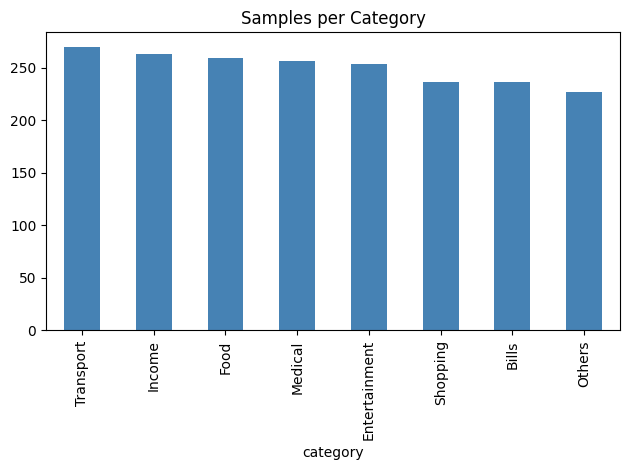

,description,category
312,UPI-BONUS-2020,Income
798,KFC india pvt ltd,Food
962,MISC bill payment,Others
157,METRO payment,Transport
1277,CASHBACK order 71700,Income


In [42]:
all_data = pd.read_csv("transactions_dataset.csv").values.tolist()

df = pd.DataFrame(all_data, columns=["description", "category"])
print(f"Total samples: {len(df)}")
df["category"].value_counts().plot(kind="bar", color="steelblue", title="Samples per Category")
plt.tight_layout()
plt.show()
df.sample(5)

In [43]:
def preprocess(text: str) -> str:
    """Clean a transaction description for vectorization."""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep alphanumeric only
    text = re.sub(r'\s+', ' ', text)            # collapse whitespace
    return text

# Verify on tricky cases
test_cases = [
    ("Swiggy Order - ₹458",      "swiggy order 458"),
    ("café coffee day",           "caf  coffee day"),   # accent stripped
    ("Amazon   Order",            "amazon order"),
    ("1mg medicines",             "1mg medicines"),
    ("  petrol   pump  ",         "petrol pump"),
]
print("Preprocessing checks:")
for inp, _ in test_cases:
    print(f"  '{inp}' → '{preprocess(inp)}'")

df["clean"] = df["description"].apply(preprocess)
print("\nSample cleaned descriptions:")
df[["description", "clean"]].sample(5)

Preprocessing checks:
  'Swiggy Order - ₹458' → 'swiggy order 458'
  'café coffee day' → 'caf coffee day'
  'Amazon   Order' → 'amazon order'
  '1mg medicines' → '1mg medicines'
  '  petrol   pump  ' → 'petrol pump'

Sample cleaned descriptions:


,description,clean
465,MISC txn 25096,misc txn 25096
825,MEDPLUS order 43240,medplus order 43240
1381,REFUND txn 86591,refund txn 86591
749,TRANSFER bill payment,transfer bill payment
227,UPI-ELECTRICITY BILL-21001,upi electricity bill 21001


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Demonstrate TF-IDF output on a few examples
demo_docs = [
    "swiggy biryani order",
    "netflix subscription monthly",
    "uber cab ride",
]

demo_vec = TfidfVectorizer(preprocessor=preprocess, ngram_range=(1,2), sublinear_tf=True)
demo_mat = demo_vec.fit_transform(demo_docs)

demo_df = pd.DataFrame(
    demo_mat.toarray(),
    columns=demo_vec.get_feature_names_out(),
    index=demo_docs
)

# Show only columns with non-zero values
nonzero_cols = demo_df.columns[(demo_df != 0).any()]
print("TF-IDF feature matrix (non-zero columns only):")
print(demo_df[nonzero_cols].round(3))

print(f"\nNote: 'uber cab' bigram gets its own feature column (not just 'uber' + 'cab' separately)")

TF-IDF feature matrix (non-zero columns only):
                              biryani  biryani order    cab  cab ride  \
swiggy biryani order            0.447          0.447  0.000     0.000   
netflix subscription monthly    0.000          0.000  0.000     0.000   
uber cab ride                   0.000          0.000  0.447     0.447   

                              monthly  netflix  netflix subscription  order  \
swiggy biryani order            0.000    0.000                 0.000  0.447   
netflix subscription monthly    0.447    0.447                 0.447  0.000   
uber cab ride                   0.000    0.000                 0.000  0.000   

                               ride  subscription  subscription monthly  \
swiggy biryani order          0.000         0.000                 0.000   
netflix subscription monthly  0.000         0.447                 0.447   
uber cab ride                 0.447         0.000                 0.000   

                              swiggy  swig

In [45]:
X = df["clean"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 80% train, 20% test
    random_state=42,  # reproducibility
    stratify=y        # maintain class proportions
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print("\nClass distribution in test set:")
print(y_test.value_counts())

Train: 1600 samples
Test:  400 samples

Class distribution in test set:
category
Transport        54
Income           53
Food             52
Entertainment    51
Medical          51
Shopping         47
Bills            47
Others           45
Name: count, dtype: int64


In [46]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess,
        ngram_range=(1, 2),
        min_df=1,
        max_features=5000,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000   
    ))
])

# Train
pipeline.fit(X, y)

# Save FULL pipeline
joblib.dump(pipeline, "categorizer.pkl")

print("✅ Pipeline saved successfully")

✅ Pipeline saved successfully


In [47]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
print(f"5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds:    {[f'{s:.3f}' for s in cv_scores]}")
print()
print("Interpretation:")
print(f"  Mean {cv_scores.mean()*100:.1f}% accuracy across all 5 splits")
print(f"  Std  {cv_scores.std()*100:.1f}% — higher std = more variance (dataset too small)")
print(f"  To reduce variance: add more training samples per category")

5-Fold CV Accuracy: 1.000 ± 0.000
Individual folds:    ['1.000', '1.000', '1.000', '1.000', '1.000']

Interpretation:
  Mean 100.0% accuracy across all 5 splits
  Std  0.0% — higher std = more variance (dataset too small)
  To reduce variance: add more training samples per category


{'memory': None, 'steps': [('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                preprocessor=<function preprocess at 0x0000023CDEC48180>,
                sublinear_tf=True)), ('clf', LogisticRegression(max_iter=1000))], 'verbose': False, 'tfidf': TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                preprocessor=<function preprocess at 0x0000023CDEC48180>,
                sublinear_tf=True), 'clf': LogisticRegression(max_iter=1000), 'tfidf__analyzer': 'word', 'tfidf__binary': False, 'tfidf__decode_error': 'strict', 'tfidf__dtype': <class 'numpy.float64'>, 'tfidf__encoding': 'utf-8', 'tfidf__input': 'content', 'tfidf__lowercase': True, 'tfidf__max_df': 1.0, 'tfidf__max_features': 5000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__preprocessor': <function preprocess at 0x0000023CDEC48180>, 'tfidf__smooth_idf': True, 'tfidf__stop_words': None, 'tfidf__strip_accents': None, 'tfidf__sublinear_tf': True, 'tfidf__t

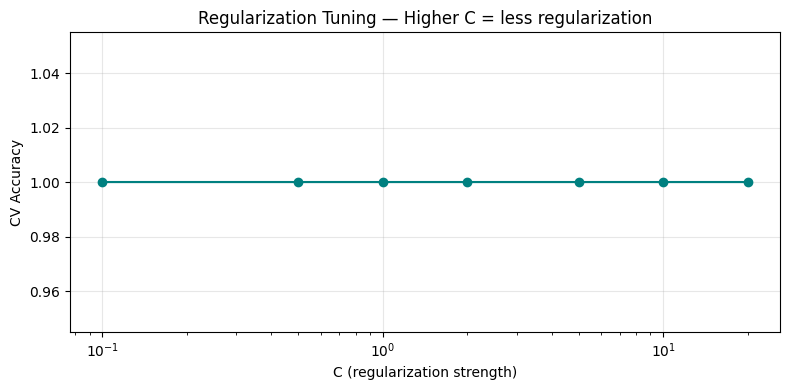

In [48]:
param_grid = {
    "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
}
print(pipeline.get_params())

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)
best_C = grid_search.best_params_['clf__C']

print(f"Best C: {best_C}")
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")

results_df = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(8, 4))
plt.plot(param_grid['clf__C'], results_df['mean_test_score'], 'o-', color='teal')
plt.fill_between(
    param_grid['clf__C'],
    results_df['mean_test_score'] - results_df['std_test_score'],
    results_df['mean_test_score'] + results_df['std_test_score'],
    alpha=0.2, color='teal'
)
plt.xscale('log')
plt.xlabel('C (regularization strength)')
plt.ylabel('CV Accuracy')
plt.title('Regularization Tuning — Higher C = less regularization')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

best_C = grid_search.best_params_['clf__C']

best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess,
        ngram_range=(1, 2),
        min_df=1,
        max_features=5000,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        C=best_C,
        max_iter=1000
    ))
])
best_pipeline.fit(X_train, y_train)
print(f"Final model trained with C={best_C}")
joblib.dump(best_pipeline, "categorizer.pkl")

best_pipeline.fit(X_train, y_train)
print(f"Final model trained with C={best_C}")
joblib.dump(best_pipeline, "categorizer.pkl")


Final model trained with C=0.1
Final model trained with C=0.1


['categorizer.pkl']

In [50]:
y_pred = best_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_acc:.3f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

Test Accuracy: 1.000

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00        47
Entertainment       1.00      1.00      1.00        51
         Food       1.00      1.00      1.00        52
       Income       1.00      1.00      1.00        53
      Medical       1.00      1.00      1.00        51
       Others       1.00      1.00      1.00        45
     Shopping       1.00      1.00      1.00        47
    Transport       1.00      1.00      1.00        54

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400



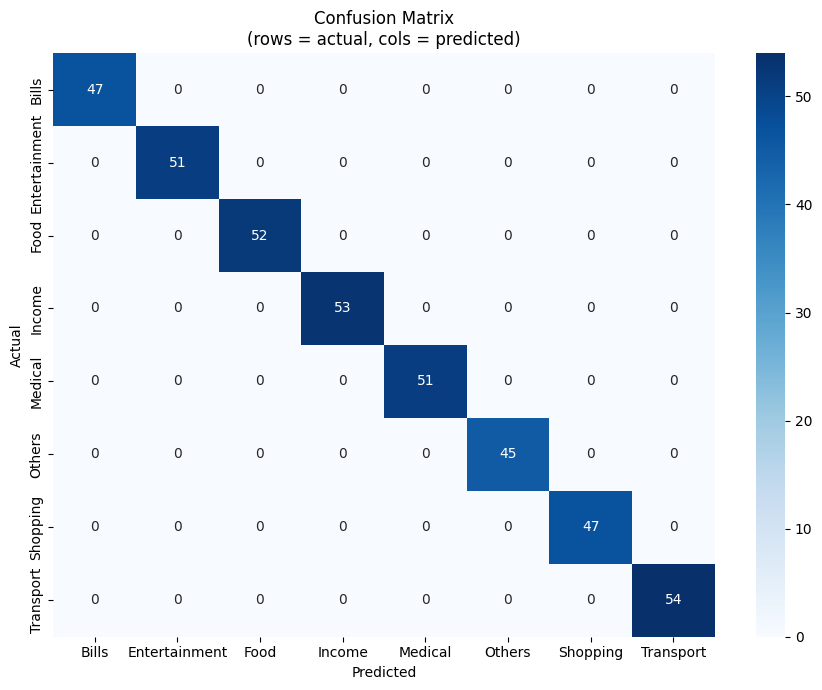

Diagonal = correct predictions. Off-diagonal = errors.
Most common confusions indicate where to add more training data.


In [51]:
cm = confusion_matrix(y_test, y_pred, labels=best_pipeline.classes_)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=best_pipeline.classes_,
    yticklabels=best_pipeline.classes_,
    cmap='Blues'
)
plt.title('Confusion Matrix\n(rows = actual, cols = predicted)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("Diagonal = correct predictions. Off-diagonal = errors.")
print("Most common confusions indicate where to add more training data.")

In [52]:
tfidf = best_pipeline.named_steps['tfidf']
clf = best_pipeline.named_steps['clf']
feature_names = tfidf.get_feature_names_out()

print("Top 10 most predictive features per category:\n")
for i, category in enumerate(clf.classes_):
    top_idx = np.argsort(clf.coef_[i])[-10:][::-1]
    top_features = [(feature_names[j], f"{clf.coef_[i][j]:.2f}") for j in top_idx]
    print(f"{category}:")
    print("  " + ", ".join([f"{w} ({s})" for w, s in top_features]))
    print()

Top 10 most predictive features per category:

Bills:
  wifi (1.15), bill (1.13), recharge (1.11), electricity (0.94), electricity bill (0.94), broadband (0.93), gas (0.90), gas bill (0.90), water (0.84), water bill (0.84)

Entertainment:
  bookmyshow (1.44), spotify (1.19), hotstar (1.19), netflix (1.10), prime video (1.04), video (1.04), prime (1.04), hotstar payment (0.50), bookmyshow payment (0.49), netflix bill (0.40)

Food:
  ubereats (1.14), zomato (1.07), dominos (1.03), swiggy (0.92), kfc (0.84), restaurant (0.69), cafe (0.68), hut (0.59), pizza hut (0.59), pizza (0.59)

Income:
  bonus (1.57), cashback (1.41), refund (1.37), credited (1.22), salary (1.22), salary credited (1.22), cashback bill (0.44), refund bill (0.44), cashback order (0.39), bonus order (0.39)

Medical:
  pharmacy (1.93), clinic (1.33), medplus (1.23), hospital (1.21), apollo pharmacy (0.91), apollo (0.91), pharmacy bill (0.55), clinic payment (0.50), pharmacy payment (0.43), medplus india (0.43)

Others:
 

In [53]:
test_inputs = [
    # Clear cases
    "swiggy biryani",
    "uber ride home",
    "netflix monthly",
    "apollo pharmacy",
    "income tax payment",
    "amazon order",
    "salary received",
    "electricity bill",
    # Ambiguous — tests robustness
    "amazon pharmacy",       # Amazon + medical context
    "uber eats delivery",    # Uber but food context
    "reliance fresh",        # Reliance could be shopping OR food
    "zomato gold",           # Zomato = food, gold = ? — tests bigrams
    "petrol fill",           # Short description
    "payment done",          # Completely generic — should default
    "xyz abc",               # Unknown words entirely
]

print(f"{'Description':<25} {'Predicted':<15} {'Confidence':<12}")
print("-" * 55)

for desc in test_inputs:
    clean = preprocess(desc)
    pred = best_pipeline.predict([desc])

    proba_all = best_pipeline.predict_proba([clean])[0]
    best_idx = proba_all.argmax()

    pred = best_pipeline.classes_[best_idx]
    confidence = proba_all[best_idx]

    flag = " ⚠️ low confidence" if confidence < 0.4 else ""

    print(f"{desc:<25} {pred:<15} {confidence:.2f}{flag}")

Description               Predicted       Confidence  
-------------------------------------------------------
swiggy biryani            Food            0.31 ⚠️ low confidence
uber ride home            Transport       0.42
netflix monthly           Entertainment   0.34 ⚠️ low confidence
apollo pharmacy           Medical         0.61
income tax payment        Others          0.19 ⚠️ low confidence
amazon order              Shopping        0.23 ⚠️ low confidence
salary received           Income          0.37 ⚠️ low confidence
electricity bill          Bills           0.45
amazon pharmacy           Medical         0.31 ⚠️ low confidence
uber eats delivery        Transport       0.42
reliance fresh            Transport       0.14 ⚠️ low confidence
zomato gold               Food            0.35 ⚠️ low confidence
petrol fill               Transport       0.14 ⚠️ low confidence
payment done              Others          0.19 ⚠️ low confidence
xyz abc                   Transport       0.14 ⚠️ l

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib
import os

# 🔥 IMPORTANT: DO NOT USE preprocessor=preprocess
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        C=best_C,
        max_iter=1000,
    ))
])

# Train on CLEAN TEXT
final_pipeline.fit(X, y)

# Save model
joblib.dump(final_pipeline, "categorizer.pkl")

print("✅ Model saved successfully")

# Verify load works
loaded = joblib.load("categorizer.pkl")

test_pred = loaded.predict(["swiggy biryani"])[0]
print("Prediction:", test_pred)

assert test_pred.lower() == "food"
print("✅ Load verification passed")

✅ Model saved successfully
Prediction: Food
✅ Load verification passed


In [55]:
loaded = joblib.load("categorizer.pkl")
print(type(loaded))

<class 'sklearn.pipeline.Pipeline'>
